## Visualizando Retratos de Fase e Trajetórias no Plano de Fase

Considere o problema da massa-mola linear:
$$
m x^{\prime \prime}+k x=0
$$

Reescrevendo num sistema de EDOs:

\begin{aligned}
&\frac{d x}{d t}=y \\
&\frac{d y}{d t}=-\frac{k}{m} x
\end{aligned}

In [1]:
import numpy as np
import matplotlib.pyplot as plt

k = 2
m = 10

In [2]:
def f(Y, t):
    y1, y2 = Y
    return [y2, -y1*k/m]

In [4]:
y1 = np.linspace(-2.0, 8.0, 20)
y2 = np.linspace(-2.0, 2.0, 20)

Y1, Y2 = np.meshgrid(y1, y2)

t = 0

u, v = np.zeros(Y1.shape), np.zeros(Y2.shape)

NI, NJ = Y1.shape

for i in range(NI):
    for j in range(NJ):
        x = Y1[i, j]
        y = Y2[i, j]
        yprime = f([x, y], t)
        u[i,j] = yprime[0]
        v[i,j] = yprime[1]

(-2.0, 2.0)

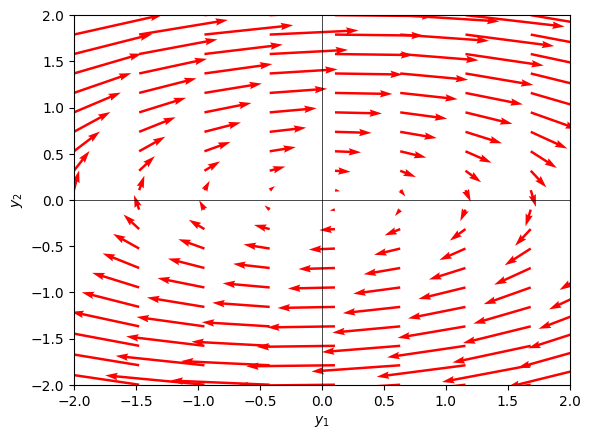

In [5]:
# Gráfico dos eixos
x1 = [-2, 2]
y1 = [0,0]
plt.plot(x1, y1, color='black', linewidth=.5)
x2 = [0,0]
y2 = [-2, 2]
plt.plot(x2, y2, color='black', linewidth=.5)

# Flexas
Q = plt.quiver(Y1, Y2, u, v, color='r', scale=10, width=.005)

plt.xlabel('$y_1$')
plt.ylabel('$y_2$')
plt.xlim([-2, 2])
plt.ylim([-2, 2])

#plt.savefig('images/phase-portrait.png')

In [6]:
from scipy.integrate import odeint

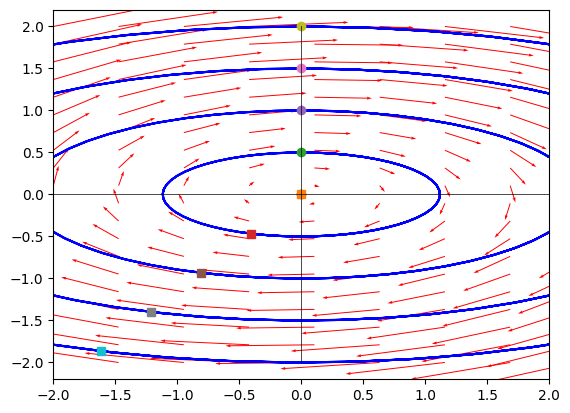

In [7]:
#for y20 in [0, 0.5, 1, 1.5, 2, 2.5]:
for y20 in [0, 0.5, 1, 1.5, 2]:
    tspan = np.linspace(0, 50, 200)
    y0 = [0.0, y20]
    ys = odeint(f, y0, tspan)
    plt.plot(ys[:,0], ys[:,1], 'b-') # path
    plt.plot([ys[0,0]], [ys[0,1]], 'o') # start
    plt.plot([ys[-1,0]], [ys[-1,1]], 's') # end

# Gráfico dos eixos
x1 = [-2, 2]
y1 = [0,0]
plt.plot(x1, y1, color='black', linewidth=.5)
x2 = [0,0]
y2 = [-2, 2]
plt.plot(x2, y2, color='black', linewidth=.5)

#Q = plt.quiver(Y1, Y2, u, v, color='r')
#Q = plt.quiver(Y1, Y2, u, v, color='r', scale=20, width=.001)
Q = plt.quiver(Y1, Y2, u, v, color='r', scale=10, width=.002)
plt.xlim([-2, 2])
#plt.savefig('images/phase-portrait-2.png')
plt.show()

### Gráficos posição versus tempo




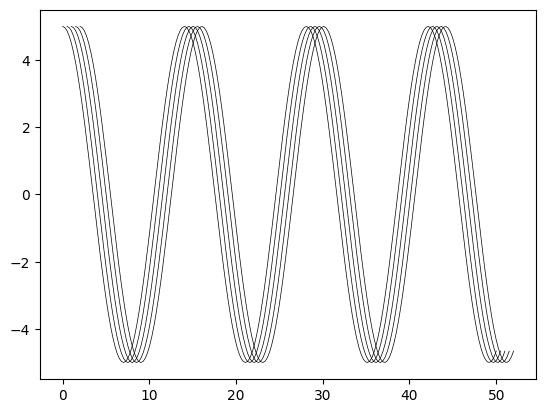

In [8]:
for t0 in [0, 0.5, 1, 1.5, 2]:
    tspan = np.linspace(0+t0, 50+t0, 200)
    y0 = [5, 0.0]
    ys = odeint(f, y0, tspan)
    plt.plot(tspan,ys[:,0], color='black', linewidth=.5)
